<a href="https://colab.research.google.com/github/Hozard0/-/blob/main/ITvTES_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Задание
Изучить синтаксис функций, предназначенных для построения трёхмерных графиков или их проекций: для Python в библиотеке Matplotlib: `plot_wireframe, plot_surface, plot_trisurf, contour, contourf` и вспомогательной `meshgrid`, а также синтаксис функций `scipy.optimize.minimize` и `scipy.optimize.shgo`.
Составить конспект по данным функциям.

1. `numpy.meshgrid`
используется для создания сетки координат из векторов.
* `X, Y = np.meshgrid(x, y)`: принимает одномерные массивы x и y, возвращает двумерные матрицы координат.
* `indexing`: параметр `("ij" или "xy")`, определяющий порядок осей.
2. `plot_wireframe`
построение каркасной (проволочной) трехмерной поверхности.
* `ax.plot_wireframe(X, Y, Z, *args, **kwargs)`: основные аргументы.
* `rcount, ccount`: максимальное количество строк и столбцов.
* `rstride, cstride`: шаг выборки строк и столбцов (устаревает в пользу count).
* `color`: цвет линий каркаса.
3. `plot_surface`
построение сплошной трехмерной поверхности.
* `ax.plot_surface(X, Y, Z, *args, **kwargs)`: основные аргументы.
* `cmap`: цветовая карта для окрашивания высот.
* `edgecolor`: цвет линий сетки на поверхности.
* `antialiased`: логическое значение для сглаживания.
4. `plot_trisurf`
построение поверхности по произвольно заданным точкам (триангуляция).
* `ax.plot_trisurf(x, y, z, *args, **kwargs)`: принимает одномерные массивы координат.
* `triangles`: определение пользовательской триангуляции.
* `shade`: использование теней для создания объема.
5. `contour`
построение линий уровня (изолиний) на плоскости или в объеме.
* `ax.contour(X, Y, Z, levels=N)`: создание N линий уровня.
* `colors`: задание цветов линий.
* `linestyles`: стиль линий (сплошная, пунктир).
6. `contourf`
построение заполненных областей между линиями уровня.
* `ax.contourf(X, Y, Z, levels=N, cmap='viridis')`: создание заливки.
* `alpha`: прозрачность заливки.
* `hatches`: списки символов для штриховки областей.
7. `scipy.optimize.minimize` универсальная функция для минимизации скалярной функции одной или нескольких переменных.
* `minimize(fun, x0, args=(), method=None, bounds=None, constraints=())`: основной вызов.
* `fun`: целевая функция.
* `x0`: начальное приближение.
* `method`: алгоритм оптимизации (например, 'BFGS', 'L-BFGS-B', 'SLSQP').
* `bounds`: границы для переменных в формате (min, max).
* `constraints`: ограничения в виде словарей или объектов.
8. `scipy.optimize.shgo`глобальная оптимизация методом симплициального гомологического поиска (Simplicial Homology Global Optimization).
* `shgo(func, bounds, args=(), constraints=None, n=100, iters=1)`: основной вызов.
* `bounds`: обязательный список кортежей с границами для каждой переменной.
n: количество выборочных точек для построения начального комплекса.
* `iters`: количество итераций алгоритма.
* `sampling_method`: метод выборки (`sobol`, `halton` или `simplicial`).

# 2 Задание
Построить трёхмерные и контурные графики функций, используя все указанные функции:
1. Ввести исходные данные.
2. Вычислить функцию.
3. Вывести в одном окне, но на разных графиках (см. subplot), функцию в виде 5 трехмерных графиков разного типа: **mesh, meshc, plot3, surf, surfl**.
4. Вывести в одном окне, но на разных графиках (см. subplot), функцию в виде 2 контурных графиков разного типа: **contour, contourf**.

image.png

Text(0.5, 0.92, 'surfl')

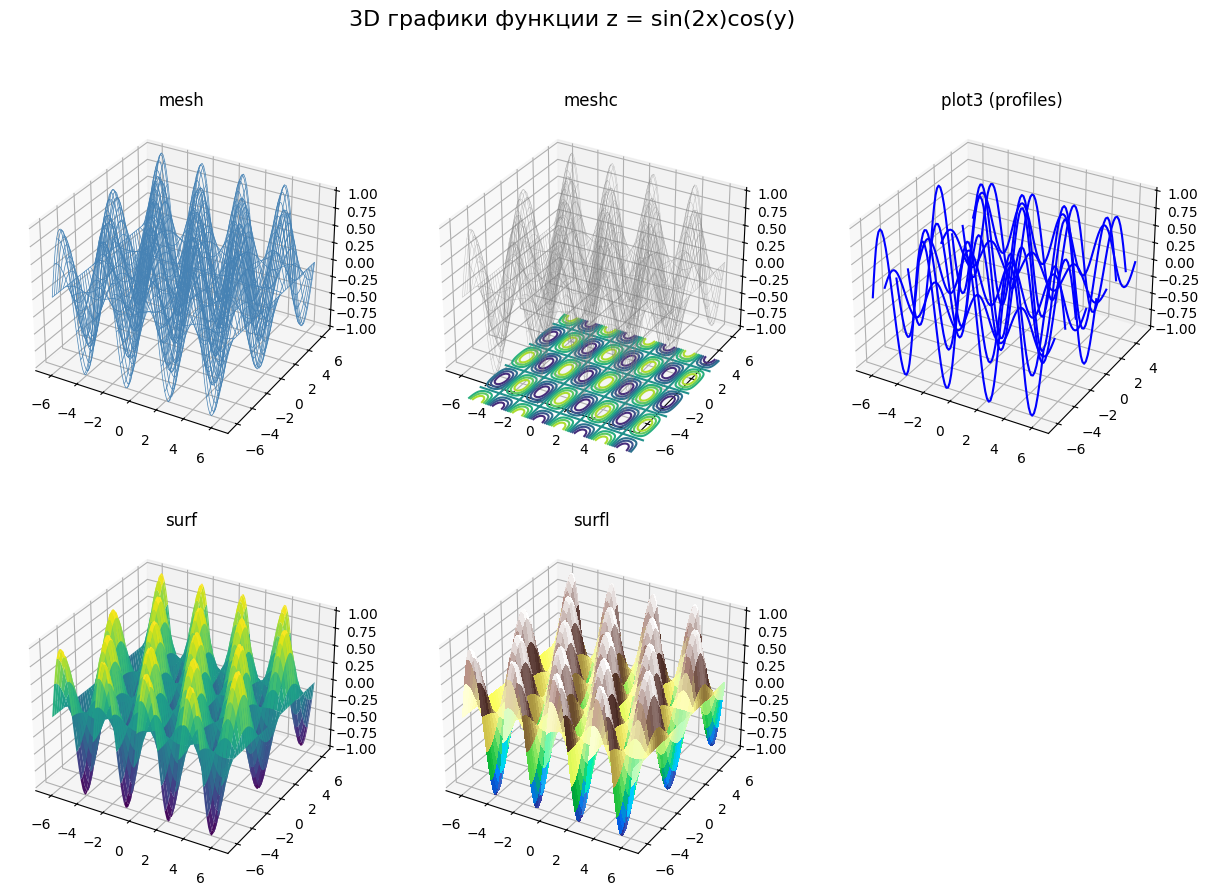

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LightSource

# Наши данные
x = np.linspace(-2 * np.pi, 2 * np.pi, 100)
y = np.linspace(-2 * np.pi, 2 * np.pi, 100)
X, Y = np.meshgrid(x, y)

# z = sin(2x) * cos(y)
Z = np.sin(2 * X) * np.cos(Y)

# Трехмерная графика
fig1 = plt.figure(figsize=(15, 10))
fig1.suptitle('3D графики функции z = sin(2x)cos(y)', fontsize=16)

# mesh
ax1 = fig1.add_subplot(2, 3, 1, projection = '3d')
ax1.plot_wireframe(X, Y, Z, color='steelblue', linewidth=0.5)
ax1.set_title('mesh')

# meshc
ax2 = fig1.add_subplot(2, 3, 2, projection='3d')
ax2.plot_wireframe(X, Y, Z, color='gray', linewidth=0.3, alpha=0.5)
ax2.contour(X, Y, Z, zdir='z', offset=np.min(Z)-0.5, cmap='viridis')
ax2.set_title('meshc')

# plot3
ax3 = fig1.add_subplot(2, 3, 3, projection='3d')
for i in range(0, len(x), 10):
    ax3.plot(X[i, :], Y[i, :], Z[i, :], color='blue')
ax3.set_title('plot3 (profiles)')

# surf
ax4 = fig1.add_subplot(2, 3, 4, projection='3d')
surf = ax4.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax4.set_title('surf')

# surfl
ax5 = fig1.add_subplot(2, 3, 5, projection='3d')
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z, cmap=cm.terrain, vert_exag=0.1, blend_mode='soft')
ax5.plot_surface(X, Y, Z, facecolors=rgb, linewidth=0, antialiased=False, shade=False)
ax5.set_title('surfl')

## 2.1 Контурная графика
Линии как в географии обозначают низину или высотку функции. Или цвет: красный - высота, синий - низина.

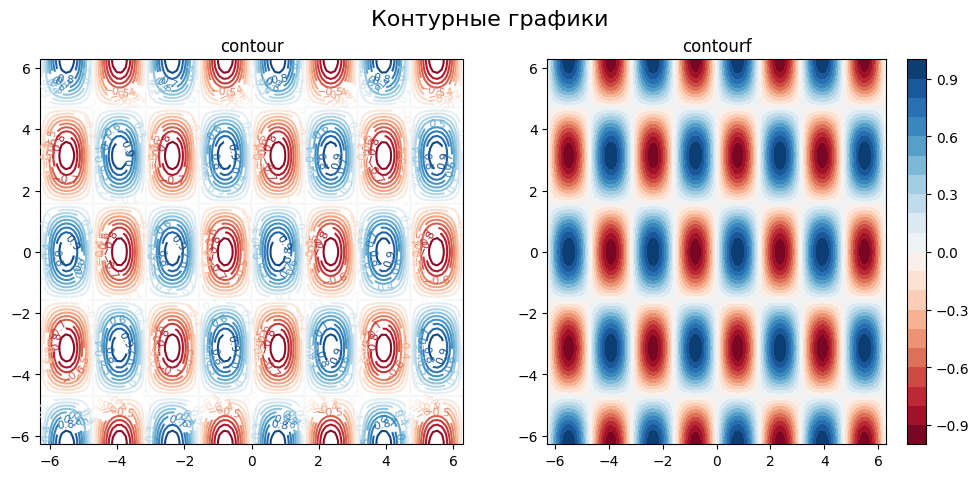

In [2]:
# Контурная графика
fig2, (c_ax1, c_ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Контурные графики', fontsize=16)

# contour
cp1 = c_ax1.contour(X, Y, Z, levels=20, cmap='RdBu')
c_ax1.clabel(cp1, inline=True, fontsize=8)
c_ax1.set_title('contour')

# contourf
cp2 = c_ax2.contourf(X, Y, Z, levels = 20, cmap = 'RdBu')
fig2.colorbar(cp2, ax = c_ax2)
c_ax2.set_title('contourf')
plt.show()

# 3 Задание
1. Постройте график функции.
2. Минимизируйте функцию (табл. 4.1), используя встроенную функцию (в Matlab `fminsearch` , а в Python `scipy.optimize.minimize` и `scipy.optimize.shgo`).
* **Целевая функция:**
   $$y_1 = \sqrt{x_1^2 + x_2^2}$$

* **Начальная точка:**
   $$x_0 = [3, 4]$$


In [3]:
from scipy.optimize import minimize, shgo

# Целевая функция

def func(x):
  return np.sqrt(x[0]**2+x[1]**2)

# Начальные данные
x0 = np.array([3, 4])

# Методом minimize (локальный поиск) минимизация
res_min = minimize(func, x0)

# Указываем границы (bounds) и делаем минимизацию через shgo (глобальный поиск)
bounds = [(-5, 5), (-5, 5)]
res_shgo = shgo(func, bounds)

# Вывод
print(f"Начальная точка: {x0}.")
print(f"Результат minimize: {res_min}, значение функции: {res_min.fun}.\n")
print(f"Результат shgo: {res_shgo}, значение функции: {res_shgo.fun}.")

Начальная точка: [3 4].
Результат minimize:   message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 3.825208949119639e-09
        x: [ 3.295e-09 -1.943e-09]
      nit: 5
      jac: [ 9.714e-01  6.406e-01]
 hess_inv: [[ 8.560e-09  2.743e-09]
            [ 2.743e-09  2.027e-08]]
     nfev: 170
     njev: 53, значение функции: 3.825208949119639e-09.

Результат shgo:  message: Optimization terminated successfully.
 success: True
     fun: 7.036265455986637e-09
    funl: [ 7.036e-09]
       x: [-4.101e-09 -5.718e-09]
      xl: [[-4.101e-09 -5.718e-09]]
     nit: 1
    nfev: 77
   nlfev: 72
   nljev: 11
   nlhev: 0, значение функции: 7.036265455986637e-09.


## Результаты половины 3 задания:
Оба метода нашли одну и ту же точку потчи 0 (если округлить до миллиардных). Функция имеет конусовидный вид, поэтому метод minimize не может подобораться из-за точности, он более плавнее, и поэтому не может вычислить наклон в бесконечно тонкой точке.
* Значение функции `fun` почти одинаково - 0.
* Координаты точки `x` тоже - 0 по обеям осям.
* `minimize` сделал 5 иттерация (шагов), а `shgo` - 1.
* `shgo` пришлось почти в два раза меньше пересчитывать формулу чем `minimize`.

**Итог**: *минимум функции в точке (0, 0). Значение функции в минимуме равно 0. Оба алгортима пришли к общему минимуму с точностью 10^-9.*

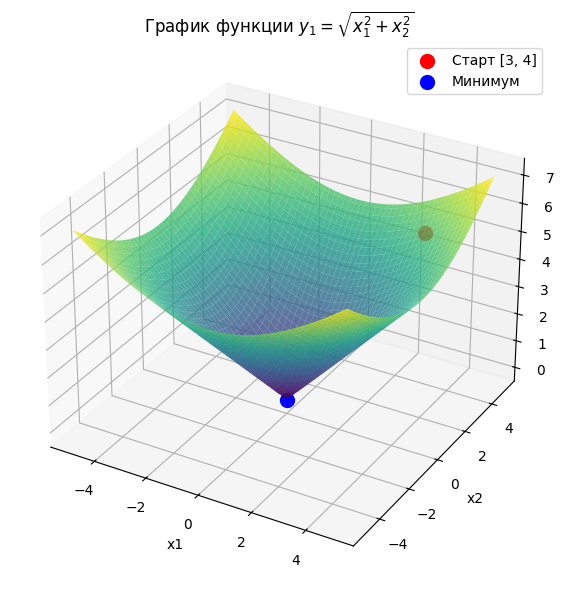

In [4]:
# Построение графика
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = np.sqrt(X**2 + Y**2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

# Начальная точка - красная
ax.scatter(x0[0], x0[1], func(x0), color='red', s=100, label='Старт [3, 4]')
# Найденный минимум - синий
ax.scatter(res_min.x[0], res_min.x[1], res_min.fun, color='blue', s=100, label='Минимум')

# Обзываем график и оси
ax.set_title(r'График функции $y_1 = \sqrt{x_1^2 + x_2^2}$')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend()

# Вывод
plt.show()


Как и говорилось - конусовидный график. Минимум в точке (0, 0), как и само значение равно 0.

# 4 Задание
Решите задачу одномерной оптимизации.

1. Постройте график функции. Убедитесь, что она на искомом интервале является унимодальной.
2. Найдите минимум функции одного аргумента (табл. 4.2), используя встроенную в Python `scipy.optimize.minimize`.
3. Найдите миминум функции одного аргумента (табл. 4.2), используя реализованный Вами метод полного перебора (полного сканирования).
4. Найдите  миминум функции одного аргумента (табл. 4.2), используя
* а) реализованный Вами модифицированный метод (по вариантам),
* б) исходный ("классический") метод.
* Оцените как изменилась скорость сходимости и точность решения после модификации: Вариант №3. Модификация метода золотого сечения. После локализации корня np.abs(b-a) < 10*eps запускается метод полного сканирования с шагом h.

**Функция одной переменной**
$$f(x) = (x -2)^2, x∈[0, 3]$$

--------------------------------------------------
Метод                     | x_min      | Вызовы f(x)
--------------------------------------------------
Scipy (minimize)          | 2.000000   | 6
Полный перебор            | 2.000000   | 300001
Золотое сечение (кл.)     | 1.999999   | 29
Золотое сечение (мод.)    | 2.000001   | 53
--------------------------------------------------


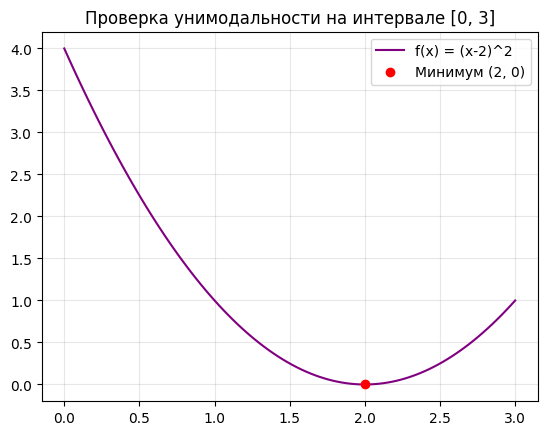

In [6]:
# Определение функции
def f(x):
  global func_calls
  func_calls += 1
  return (x-2)**2

# Исходные данные
a_init, b_init = 0, 3 # Границы
eps = 1e-5            # Точность
func_calls = 0        # Глобальный счетчик для замеров

# Через Scipy (встроенный метод)
func_calls = 0
res_scipy = minimize(f, x0=0, bounds=[(a_init, b_init)], tol=eps)
scipy_calls = func_calls

# Метод полного перебора
def full_scan(f, a, b, step):
    calls_before = func_calls
    xs = np.arange(a, b + step, step)
    ys = np.array([f(x) for x in xs])
    idx = np.argmin(ys)
    return xs[idx], ys[idx], func_calls - calls_before

func_calls = 0
x_scan, f_scan, scan_calls = full_scan(f, a_init, b_init, eps)

# Золотое сечение (классический метод)
def golden_section(f, a, b, tol):
    calls_before = func_calls
    phi = (1 + 5**0.5) / 2
    resphi = 2 - phi

    x1 = a + resphi * (b - a)
    x2 = b - resphi * (b - a)
    f1, f2 = f(x1), f(x2)

    while abs(b - a) > tol:
        if f1 < f2:
            b, x2, f2 = x2, x1, f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a, x1, f1 = x1, x2, f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)
    return (a + b) / 2, func_calls - calls_before

func_calls = 0
x_gold, gold_calls = golden_section(f, a_init, b_init, eps)

# Золотое сечение (модифицированный метод)
def modified_gold(f, a, b, tol):
    calls_before = func_calls
    phi = (1 + 5**0.5) / 2
    resphi = 2 - phi

    # Шаг 1: Золотое сечение до порога 10*eps
    while abs(b - a) > 10 * tol:
        x1 = a + resphi * (b - a)
        x2 = b - resphi * (b - a)
        if f(x1) < f(x2):
            b = x2
        else:
            a = x1

    # Шаг 2: Полное сканирование на остатке интервала с шагом h = tol
    x_min, _, _ = full_scan(f, a, b, tol)
    return x_min, func_calls - calls_before

func_calls = 0
x_mod, mod_calls = modified_gold(f, a_init, b_init, eps)

# Вывод результатов
print("-" * 50)
print(f"{'Метод':<25} | {'x_min':<10} | {'Вызовы f(x)':<10}")
print("-" * 50)
print(f"{'Scipy (minimize)':<25} | {res_scipy.x[0]:<10.6f} | {scipy_calls}")
print(f"{'Полный перебор':<25} | {x_scan:<10.6f} | {scan_calls}")
print(f"{'Золотое сечение (кл.)':<25} | {x_gold:<10.6f} | {gold_calls}")
print(f"{'Золотое сечение (мод.)':<25} | {x_mod:<10.6f} | {mod_calls}")
print("-" * 50)

# Настройка и вывод графика
x_plot = np.linspace(a_init, b_init, 100)
plt.plot(x_plot, (x_plot - 2)**2, color='purple', label='f(x) = (x-2)^2')
plt.scatter(2, 0, color='red', zorder=5, label='Минимум (2, 0)')
plt.title(r'Проверка унимодальности на интервале [0, 3]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Вывод: модификация метода золотого сечения (Вариант №3) привела к увеличению вычислительных затрат (53 вызова против 29), однако позволила детально исследовать локализованный интервал методом полного сканирования. Для гладких функций, таких как парабола, классический метод остается более быстрым, но модификация повышает надежность поиска в окрестности экстремума.

В остальном все методы показали себя хорошо, но, думаю, для больших вычислений подойдет через Scipy, чем через полный перебор тот же, 6 < 300001.

# 6 Задание
Решите задачу минимизации линейной целевой функции от нескольких аргументов при линейных ограничениях в Python, используя встроенную функцию linprog.

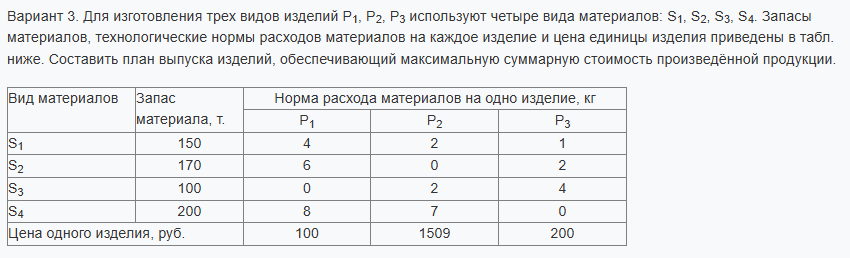

In [8]:
from scipy.optimize import linprog

# Коэф. целевой функции (умножаем на -1 для поиск максимума)
c = [-100, -1509, -200]

# Матрица коэф. ограничений
A = [[4, 2, 1],
     [6, 0, 2],
     [0, 2, 4],
     [8, 7, 0]
]

# Вектор свободных членов
b = [150, 170, 100, 200]

# Граничные условия для x1, x2, x3 (все больше 0)
x_bounds = (0, None)

# Решение задачи методом simplex
res = linprog(c, A_ub = A, b_ub = b, bounds = [x_bounds, x_bounds, x_bounds], method = 'highs')

# Вывод результатов
if res.success:
  print(f'Результат: {res.message}.\n')
  print(f"Оптимальный план выпуска:")
  print(f"P1 (x1) = {res.x[0]:.2f} шт.")
  print(f"P2 (x2) = {res.x[1]:.2f} шт.")
  print(f"P3 (x3) = {res.x[2]:.2f} шт.\n")
  print(f"Максимальная стоимость: {-res.fun:.2f} руб.")
else:
  print("Решение не найдено...")


Результат: Optimization terminated successfully. (HiGHS Status 7: Optimal).

Оптимальный план выпуска:
P1 (x1) = 0.00 шт.
P2 (x2) = 28.57 шт.
P3 (x3) = 10.71 шт.

Максимальная стоимость: 45257.14 руб.


Судя по всему P1(x1) не прибыльный вариант, выгоднее другие варианты, P2(x2) видимо самый прибльный. А P3(x3) дополнение к плану. Если следовать по другому варианту, то прибыль уменьшится, также мы не может изделия выпускать дробно, поэтому стоит округлить до целых. Все это в теории.

# Ответы на контрольные вопросы:

## 1. Постановка задачи оптимизации
**Задача оптимизации** - это процесс нахождения наилучшего (экстремального) значения целевой функции при соблюдении заданных условий.

*   **Целевая функция:** математическое выражение $f(x)$, которое нужно минимизировать (например, затраты) или максимизировать (например, прибыль).
*   **Параметры:** переменные $x$, от которых зависит значение функции.
*   **Критерий:** правило, по которому выбирается лучший вариант (min или max).

## 2. Постановка задачи многомерной оптимизации
Задача поиска экстремума функции нескольких переменных: $f(x_1, x_2, \dots, x_n) \to \min (\max)$.

*   В отличие от одномерной задачи, здесь мы ищем точку в **n-мерном пространстве**.
*   **Геометрический смысл:** поиск самой низкой или высокой точки на сложной поверхности (рельефе).
*   Требует одновременного изменения всех аргументов функции для нахождения оптимального вектора решения $X^*$.


## 3. Методы безусловной оптимизации
Используются, когда на аргументы функции не наложено никаких дополнительных ограничений.

*   **Методы без вычисления производных (прямые методы):**
    *   Метод Нелдера-Мида (симплекс-метод).
    *   Метод покоординатного спуска.
*   **Градиентные методы (требуют производную):**
    *   Метод наискорейшего спуска.
    *   Метод сопряженных градиентов.
    *   Метод Ньютона.

## 4. Методы оптимизации с ограничениями
Применяются, когда область поиска ограничена (равенствами или неравенствами), например, ограничен бюджет или запасы ресурсов.

*   **Методы штрафных функций:** преобразование задачи с ограничениями в безусловную путем добавления "штрафа" за выход из допустимой области.
*   **Линейное программирование (Симплекс-метод):** решение задач, где целевая функция и ограничения — линейные.
*   **Метод множителей Лагранжа:** математический метод для поиска экстремума при ограничениях-равенствах.


## 5. Решение задач оптимизации в Matlab
Matlab предоставляет встроенные функции в составе **Optimization Toolbox**:


| Функция | Назначение |
| :--- | :--- |
| `fminbnd` | Минимизация функции одной переменной на заданном интервале. |
| `fminsearch` | Многомерная безусловная оптимизация (метод Нелдера-Мида). |
| `fmincon` | Общая минимизация при наличии различных ограничений. |
| `linprog` | Решение задач линейного программирования (как в задаче о производстве). |
| `quadprog` | Решение задач квадратичного программирования. |
